# Problem 6 - PCA with SVD

## Interview question

Implement PCA. Given `X: [N, D]`, return the top `num_components` principal components and the projected data.

## What is being asked

You need to center the data, find directions of maximum variance, and project the data onto those directions. SVD is usually the most stable implementation.

## Clarifying questions

- Should I use covariance eigendecomposition or SVD?
- Should outputs be principal directions, projected data, or reconstructed data?
- Are features already standardized?

## Solution

/tmp/ipykernel_2885932/2046596241.py:34: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(np.random.rand(2), np.random.rand(2, 2), N)


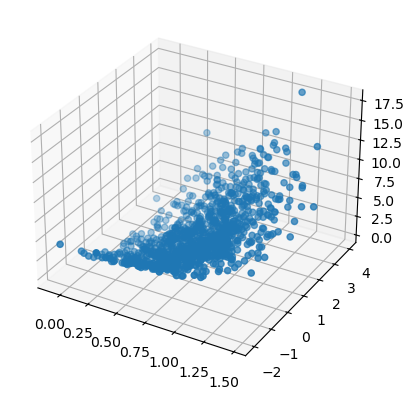

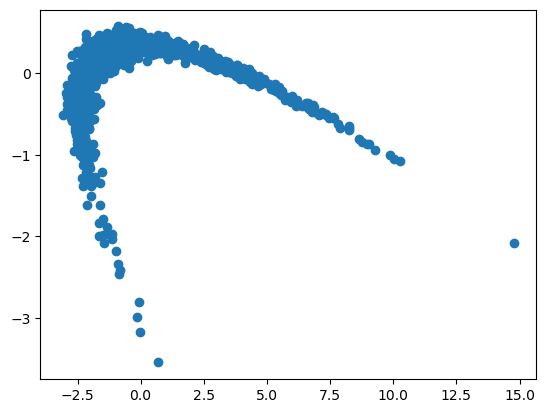

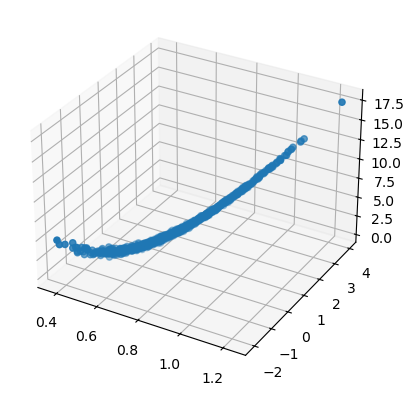

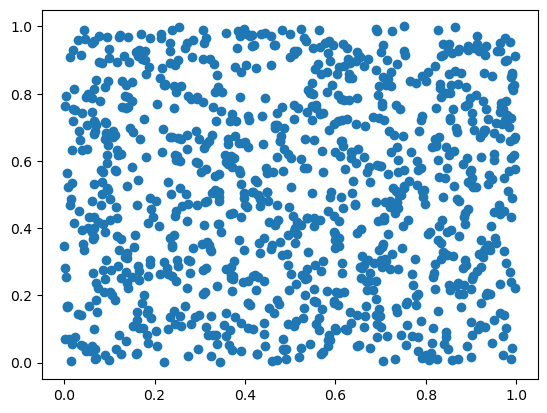

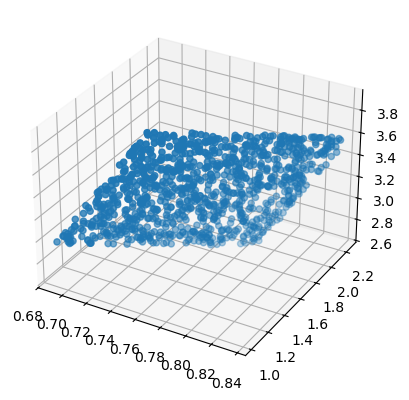

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def pca_svd(X, num_components):
    """
    X: [N, D]
    Returns:
        X_proj: [N, num_components]
        components: [num_components, D]
        explained_variance: [num_components]
        mean: [D]
    """
    mean = X.mean(axis=0, keepdims=True)      # [1, D]
    X_centered = X - mean                     # [N, D]

    # X_centered = U S Vt
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    components = Vt[:num_components]         # [C, D]
    X_proj = X_centered @ components.T        # [N, C]

    explained_variance = (S[:num_components] ** 2) / (X.shape[0] - 1)
    return X_proj, components, explained_variance, mean.squeeze(0)


def pca_reconstruct(X_proj, components, mean):
    return X_proj @ components + mean


if __name__ == "__main__":
    N = 1000
    D = 3

    X = np.random.multivariate_normal(np.random.rand(2), np.random.rand(2, 2), N)
    X = np.concatenate((X, X[:, 0:1]+X[:, 1:2]**2+np.random.rand(N, 1)*0.6), -1)

    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], X[:, 2])
    plt.show()

    X_proj, components, _, mean, = pca_svd(X, 2)

    plt.scatter(X_proj[:, 0], X_proj[:, 1])
    plt.show()

    X_recon = pca_reconstruct(X_proj, components, mean)

    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.scatter3D(X_recon[:, 0], X_recon[:, 1], X_recon[:, 2])
    plt.show()

    random_X = np.random.rand(N, 2)
    
    plt.scatter(random_X[:, 0], random_X[:, 1])
    plt.show()

    X_recon_rand = pca_reconstruct(random_X, components, mean)

    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.scatter3D(X_recon_rand[:, 0], X_recon_rand[:, 1], X_recon_rand[:, 2])
    plt.show()
